In [1]:
%matplotlib inline


# Simulating results

CODE Taken from Soocermatic Course 

We now use a Poisson regression to fit a model to the Premier League
and then we use the estimated values to simulate results between
two teams.

This code is adapted from
https://dashee87.github.io/football/python/predicting-football-results-with-statistical-modelling/


In [2]:
# importing the tools required for the Poisson regression model
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn
from scipy.stats import poisson,skellam

## Import data
Here we use football-data.co.uk



In [5]:
df1 = pd.read_csv(r"C:\Users\lolen\Downloads\E0.csv")
df2 = pd.read_csv(r"C:\Users\lolen\Downloads\E0 (1).csv")
df3 = pd.read_csv(r"C:\Users\lolen\Downloads\E0 (2).csv")
df4 = pd.read_csv(r"C:\Users\lolen\Downloads\E0 (3).csv")

# epl = pd.concat([df1, df2, df3, df4], ignore_index=True)
epl =df1
epl = epl[['HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'HS', 'AS', 'HST', 'AST']]
epl = epl.rename(columns={
    'FTHG': 'HomeGoals',
    'FTAG': 'AwayGoals',
    'HS':   'HomeShots',
    'AS':   'AwayShots',
    'HST':  'HomeShotsOnTarget',
    'AST':  'AwayShotsOnTarget',
})


In [6]:
epl

,HomeTeam,AwayTeam,HomeGoals,AwayGoals,HomeShots,AwayShots,HomeShotsOnTarget,AwayShotsOnTarget
0,Liverpool,Bournemouth,4,2,19,10,10,3
1,Aston Villa,Newcastle,0,0,3,16,3,3
2,Brighton,Fulham,1,1,10,7,4,2
3,Sunderland,West Ham,3,0,10,12,5,4
4,Tottenham,Burnley,3,0,16,14,6,4
...,...,...,...,...,...,...,...,...
286,Brighton,Arsenal,0,1,11,7,3,2
287,Fulham,West Ham,0,1,13,9,5,3
288,Man City,Nott'm Forest,2,2,21,9,7,4
289,Newcastle,Man United,2,1,12,14,5,5


## Perform the regression
In the fit, we include a parameter for home advantage.
Team and opponent are fixed effects.



In [7]:
goal_model_data = pd.concat([
    epl[['HomeTeam', 'AwayTeam', 'HomeGoals', 'HomeShots', 'HomeShotsOnTarget']].assign(home=1).rename(
        columns={'HomeTeam': 'team', 'AwayTeam': 'opponent',
                 'HomeGoals': 'goals', 'HomeShots': 'shots', 'HomeShotsOnTarget': 'shots_on_target'}),
    epl[['AwayTeam', 'HomeTeam', 'AwayGoals', 'AwayShots', 'AwayShotsOnTarget']].assign(home=0).rename(
        columns={'AwayTeam': 'team', 'HomeTeam': 'opponent',
                 'AwayGoals': 'goals', 'AwayShots': 'shots', 'AwayShotsOnTarget': 'shots_on_target'})
])

poisson_model = smf.glm(
    formula="goals ~ home + team + opponent + shots + shots_on_target",
    data=goal_model_data,
    family=sm.families.Poisson()
).fit()
poisson_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  goals   No. Observations:                  582
Model:                            GLM   Df Residuals:                      540
Model Family:                 Poisson   Df Model:                           41
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -759.35
Date:                Sat, 14 Mar 2026   Deviance:                       454.08
Time:                        13:50:02   Pearson chi2:                     369.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.2997
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                     -0.3323      0.267     -1.244      0.213      -0.856       0.191
team[T.Aston Villa]           -0.3560      0.210     -1.698      0.090      -0.767       0.055
team[T.Bournemouth]           -0.2768      0.200     -1.381      0.167      -0.670       0.116
team[T.Brentford]             -0.2284      0.203     -1.125      0.261      -0.626       0.169
team[T.Brighton]              -0.3209      0.210     -1.525      0.127      -0.733       0.091
team[T.Burnley]               -0.3637      0.224     -1.621      0.105      -0.803       0.076
team[T.Chelsea]               -0.0823      0.191     -0.431      0.667      -0.457       0.292
team[T.Crystal Palace]        -0.3913      0.220     -1.780      0.075      -0.822       0.040
team[T.Everton]               -0.3392      0.220     -1.544      0.123      -0.770       0.091
team[T.Fulham]                -0.1219      0.208     -0.586      0.558      -0.530       0.286
team[T.Leeds]                 -0.2225      0.213     -1.046      0.295      -0.639       0.194
team[T.Liverpool]             -0.0768      0.198     -0.388      0.698      -0.465       0.311
team[T.Man City]              -0.0597      0.186     -0.321      0.749      -0.424       0.305
team[T.Man United]            -0.2361      0.195     -1.210      0.226      -0.619       0.146
team[T.Newcastle]             -0.3320      0.204     -1.628      0.104      -0.732       0.068
team[T.Nott'm Forest]         -0.5460      0.231     -2.362      0.018      -0.999      -0.093
team[T.Sunderland]            -0.4252      0.230     -1.847      0.065      -0.876       0.026
team[T.Tottenham]             -0.2577      0.211     -1.224      0.221      -0.671       0.155
team[T.West Ham]              -0.3468      0.217     -1.597      0.110      -0.773       0.079
team[T.Wolves]                -0.8176      0.255     -3.205      0.001      -1.318      -0.318
opponent[T.Aston Villa]        0.1821      0.280      0.650      0.516      -0.367       0.731
opponent[T.Bournemouth]        0.3972      0.266      1.492      0.136      -0.125       0.919
opponent[T.Brentford]          0.4184      0.270      1.548      0.122      -0.111       0.948
opponent[T.Brighton]           0.2990      0.275      1.087      0.277      -0.240       0.838
opponent[T.Burnley]            0.5317      0.265      2.007      0.045       0.012       1.051
opponent[T.Chelsea]            0.2450      0.278      0.883      0.377      -0.299       0.789
opponent[T.Crystal Palace]     0.1469      0.277      0.531      0.595      -0.395       0.689
opponent[T.Everton]            0.2733      0.280      0.974      0.330      -0.276       0.823
opponent[T.Fulham]             0.4783      0.266      1.801      0.072      -0.042       0.999
opponent[T.Leeds]              0.5279      

In [13]:
# Set teams here
home_team = 'West Ham'
away_team = 'Man City'

# Use each team's average shots & shots on target from training data
def team_avg(team):
    d = goal_model_data[goal_model_data['team'] == team]
    return d['shots'].mean(), d['shots_on_target'].mean()

home_shots, home_sot = team_avg(home_team)
away_shots, away_sot = team_avg(away_team)

# Predict expected goals
home_score_rate = poisson_model.predict(pd.DataFrame(data={
    'team': home_team, 'opponent': away_team, 'home': 1,
    'shots': home_shots, 'shots_on_target': home_sot
}, index=[1]))

away_score_rate = poisson_model.predict(pd.DataFrame(data={
    'team': away_team, 'opponent': home_team, 'home': 0,
    'shots': away_shots, 'shots_on_target': away_sot
}, index=[1]))

print(home_team + ' against ' + away_team + ' expect to score: ' + str(home_score_rate.values[0].round(3)))
print(away_team + ' against ' + home_team + ' expect to score: ' + str(away_score_rate.values[0].round(3)))

# Simulate a result
home_goals = np.random.poisson(home_score_rate)
away_goals = np.random.poisson(away_score_rate)
print(home_team + ': ' + str(home_goals[0]))
print(away_team + ': ' + str(away_goals[0]))


West Ham against Man City expect to score: 0.871
Man City against West Ham expect to score: 1.951
West Ham: 0
Man City: 1


## Simulating a game
Let's now simulate a match between City and Arsenal



In [15]:
# Set teams here
home_team = 'Arsenal'
away_team = 'Leeds'

# Use each team's average shots & shots on target from training data
home_shots, home_sot = team_avg(home_team)
away_shots, away_sot = team_avg(away_team)

# Predict expected goals
home_score_rate = poisson_model.predict(pd.DataFrame(data={
    'team': home_team, 'opponent': away_team, 'home': 1,
    'shots': home_shots, 'shots_on_target': home_sot
}, index=[1]))

away_score_rate = poisson_model.predict(pd.DataFrame(data={
    'team': away_team, 'opponent': home_team, 'home': 0,
    'shots': away_shots, 'shots_on_target': away_sot
}, index=[1]))

print(home_team + ' against ' + away_team + ' expect to score: ' + str(home_score_rate.values[0].round(3)))
print(away_team + ' against ' + home_team + ' expect to score: ' + str(away_score_rate.values[0].round(3)))

# Simulate a result
home_goals = np.random.poisson(home_score_rate)
away_goals = np.random.poisson(away_score_rate)
print(home_team + ': ' + str(home_goals[0]))
print(away_team + ': ' + str(away_goals[0]))


Arsenal against Leeds expect to score: 2.299
Leeds against Arsenal expect to score: 0.797
Arsenal: 5
Leeds: 1


## Two-dimensional histogram of scores
This gives the probability of different score lines.



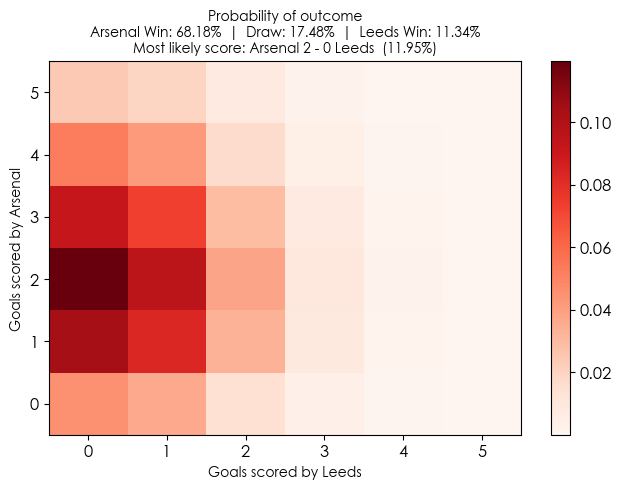

Arsenal Win: 68.18%  |  Draw: 17.48%  |  Leeds Win: 11.34%
Most likely score: Arsenal 2 - 0 Leeds  (11.95%)


In [16]:
# Code to calculate the goals for the match.
def simulate_match(foot_model, homeTeam, awayTeam, max_goals=10):
    home_shots, home_sot = team_avg(homeTeam)
    away_shots, away_sot = team_avg(awayTeam)

    home_goals_avg = foot_model.predict(pd.DataFrame(data={
        'team': homeTeam, 'opponent': awayTeam, 'home': 1,
        'shots': home_shots, 'shots_on_target': home_sot
    }, index=[1])).values[0]

    away_goals_avg = foot_model.predict(pd.DataFrame(data={
        'team': awayTeam, 'opponent': homeTeam, 'home': 0,
        'shots': away_shots, 'shots_on_target': away_sot
    }, index=[1])).values[0]

    team_pred = [[poisson.pmf(i, team_avg) for i in range(0, max_goals + 1)] for team_avg in
                 [home_goals_avg, away_goals_avg]]
    return np.outer(np.array(team_pred[0]), np.array(team_pred[1]))

# Fill in the matrix
max_goals = 5
score_matrix = simulate_match(poisson_model, home_team, away_team, max_goals)

# Home, draw, away probabilities
homewin = np.sum(np.tril(score_matrix, -1))
draw = np.sum(np.diag(score_matrix))
awaywin = np.sum(np.triu(score_matrix, 1))
prob_text = f"{home_team} Win: {homewin:.2%}  |  Draw: {draw:.2%}  |  {away_team} Win: {awaywin:.2%}"

# Most likely scoreline
home_goals_ml, away_goals_ml = np.unravel_index(np.argmax(score_matrix), score_matrix.shape)
most_likely_score = f"Most likely score: {home_team} {home_goals_ml} - {away_goals_ml} {away_team}  ({score_matrix[home_goals_ml, away_goals_ml]:.2%})"

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
pos = ax.imshow(score_matrix, extent=[-0.5, max_goals+0.5, -0.5, max_goals+0.5],
                aspect='auto', cmap=plt.cm.Reds, origin='lower')
cbar = fig.colorbar(pos, ax=ax)

cbar.ax.tick_params(labelsize=12, labelfontfamily='Century Gothic')
ax.set_title('Probability of outcome\n' + prob_text + '\n' + most_likely_score, font="Century Gothic", size=10)
plt.xlim((-0.5, 5.5))
plt.ylim((-0.5, 5.5))
plt.xticks(fontname='Century Gothic', fontsize=12)
plt.yticks(fontname='Century Gothic', fontsize=12)

plt.tight_layout()
ax.set_xlabel('Goals scored by ' + away_team, font="Century Gothic")
ax.set_ylabel('Goals scored by ' + home_team, font="Century Gothic")
plt.show()

print(prob_text)
print(most_likely_score)
